In [2]:
import os
print(os.getcwd())

C:\Users\uttra


In [3]:
import os
print(os.listdir(r"C:\Users\uttra\OneDrive\Desktop\help!\diabetes"))

['diabetes.csv']


In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\uttra\OneDrive\Desktop\help!\diabetes\diabetes.csv")

print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [11]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


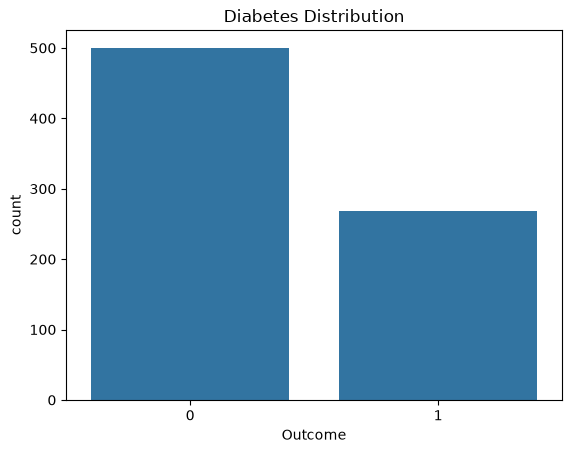

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Distribution")
plt.show()

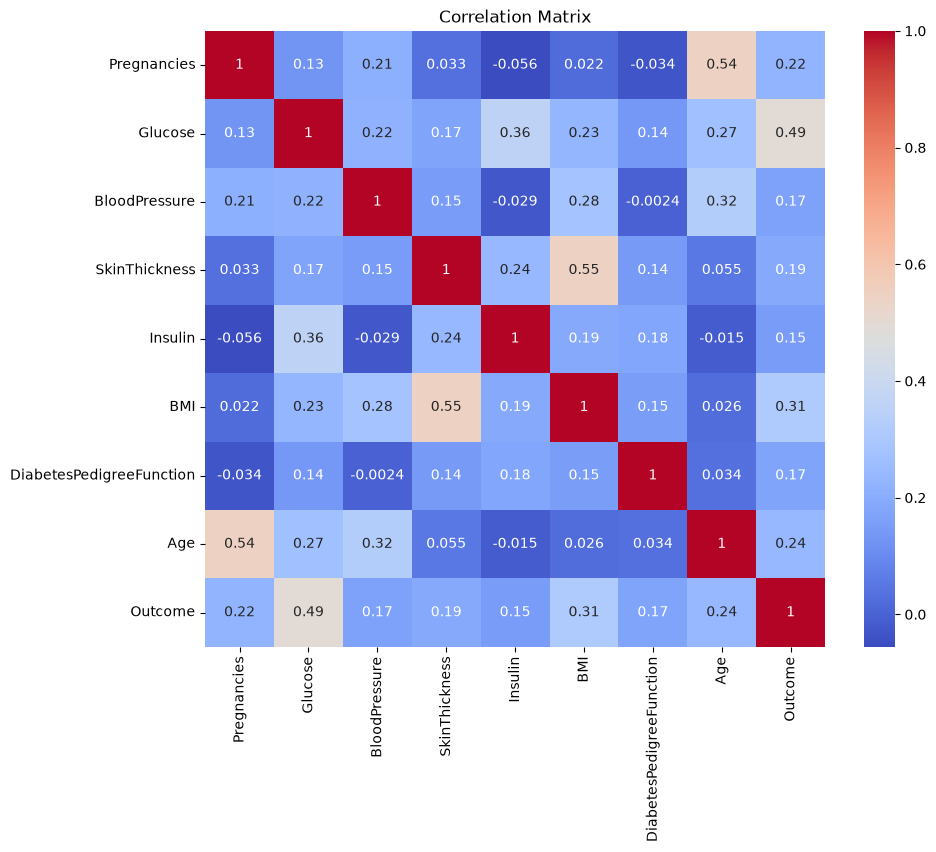

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [15]:
corr = df.corr()

print(corr['Outcome'].sort_values(ascending=False))

ValueError: could not convert string to float: 'Obese'

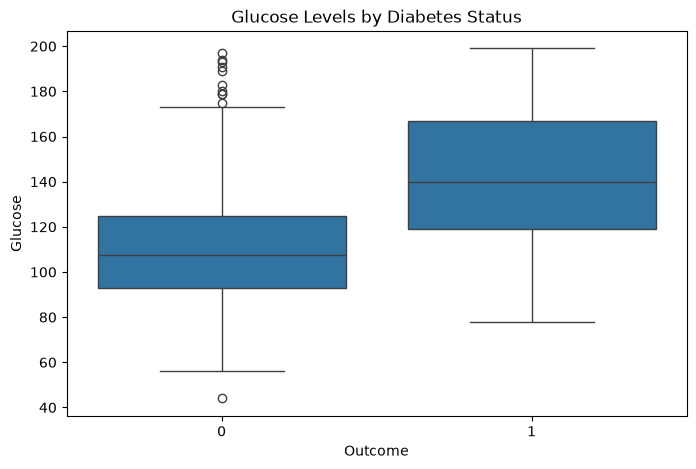

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome',
            y='Glucose',
            data=df)

plt.title("Glucose Levels by Diabetes Status")
plt.show()

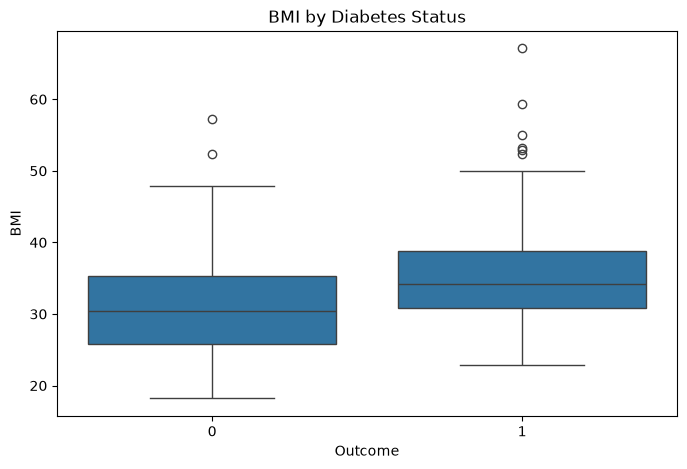

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome',
            y='BMI',
            data=df)

plt.title("BMI by Diabetes Status")
plt.show()

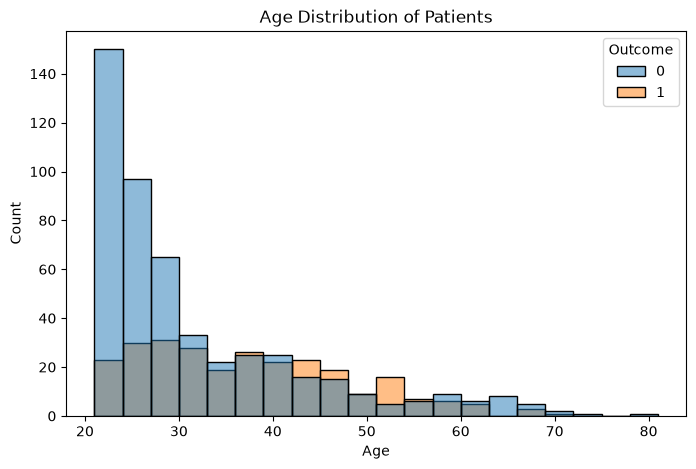

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,
             x='Age',
             hue='Outcome',
             bins=20)

plt.title("Age Distribution of Patients")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.7597402597402597


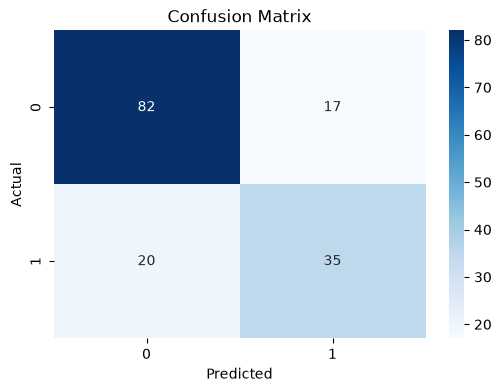

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
def risk_level(row):

    score = 0

    if row["Glucose"] > 140:
        score += 2

    if row["BMI"] > 30:
        score += 1

    if row["Age"] > 45:
        score += 1

    if score <= 1:
        return "Low"

    elif score == 2:
        return "Moderate"

    elif score == 3:
        return "High"

    else:
        return "Critical"

df["RiskLevel"] = df.apply(risk_level, axis=1)

In [21]:
df["RiskLevel"].value_counts()

RiskLevel
Low         545
High        127
Moderate     60
Critical     36
Name: count, dtype: int64

In [19]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'BMI_Category']


In [22]:
def age_group(age):

    if age < 30:
        return "20-29"

    elif age < 40:
        return "30-39"

    elif age < 50:
        return "40-49"

    else:
        return "50+"

df["Age_Group"] = df["Age"].apply(age_group)

In [23]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'BMI_Category', 'RiskLevel', 'Age_Group']


///////////////////////////////////////////////////////////////////////////////////////////////////

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [28]:
features = df[
    ['Glucose',
     'BMI',
     'Age',
     'BloodPressure']
]

scaler = StandardScaler()

scaled = scaler.fit_transform(features)
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(scaled)
df.groupby("Cluster")[
    ['Glucose','BMI','Age','BloodPressure']
].mean()

,Glucose,BMI,Age,BloodPressure
Cluster,,,,
0,159.464789,39.698592,33.077465,77.746479
1,105.726891,34.344958,30.180672,77.109244
2,107.167969,27.883594,25.980469,61.722656
3,137.803030,30.096970,53.015152,78.787879


In [29]:
df["RiskLevel"].value_counts()

RiskLevel
Low         545
High        127
Moderate     60
Critical     36
Name: count, dtype: int64

In [30]:
cluster_names = {
    0: "High-Risk Obese",
    1: "Obese Moderate-Risk",
    2: "Young Healthy",
    3: "Older High-Risk"
}

df["Patient_Group"] = df["Cluster"].map(cluster_names)

In [31]:
df["Patient_Group"].value_counts()

Patient_Group
Young Healthy          256
Obese Moderate-Risk    238
High-Risk Obese        142
Older High-Risk        132
Name: count, dtype: int64

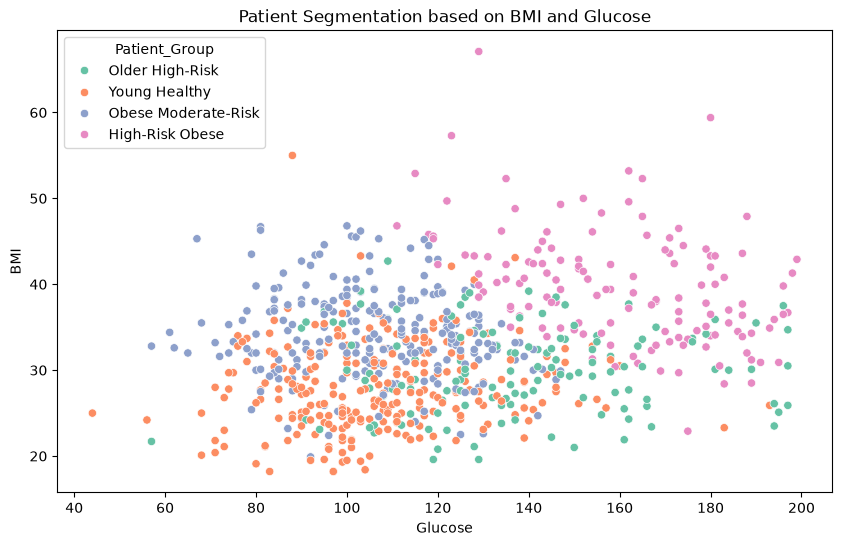

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Patient_Group",
    palette="Set2"
)

plt.title("Patient Segmentation based on BMI and Glucose")
plt.show()

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [36]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)

# Keep only numeric columns
X = X.select_dtypes(include=['int64','float64'])

y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7727272727272727


In [38]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
1,Glucose,0.259372
5,BMI,0.162542
7,Age,0.147397
6,DiabetesPedigreeFunction,0.117283
2,BloodPressure,0.088270
0,Pregnancies,0.078288
4,Insulin,0.075817
3,SkinThickness,0.071030


In [39]:
from xgboost import XGBClassifier

In [40]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.7272727272727273


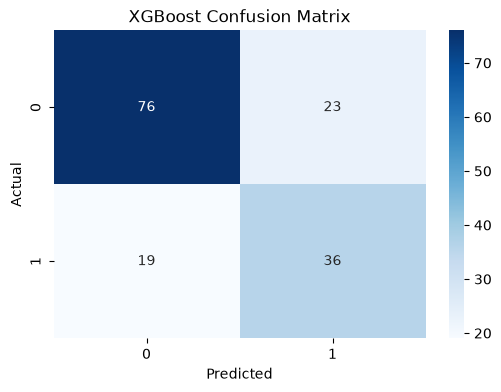

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82        99
           1       0.67      0.71      0.69        55

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.76       154
weighted avg       0.78      0.77      0.77       154



In [43]:
df.to_csv("diabetes_final.csv", index=False)